In [1]:
%%capture
!pip install huggingface_hub safetensors torch matplotlib numpy


## SLERP Angle Diagnostic

Tests whether SLERP's catastrophic GSM8K collapse (0.005–0.01 EM across all 6 merge orderings — order-independent, so not an associativity artifact) is explained by **concentration of measure**: computing one angle over an entire flattened weight matrix (tens of thousands of dims) may put every adapter pair near 90° regardless of real task similarity, giving SLERP's spherical interpolation little real signal to use.

No base model or Unsloth needed — this only reads adapter weights directly from HF.

In [2]:
from safetensors.torch import load_file
from huggingface_hub import hf_hub_download
import json
import torch

def get_lora_deltas(repo_name: str, hf_username: str = "Srishtik", lora_alpha: int = None, r: int = None) -> dict:
    """Compute ΔW = lora_B @ lora_A * (alpha/r) directly from adapter weights.

    r and lora_alpha are read from the adapter's own adapter_config.json unless
    explicitly overridden — do not assume all adapters share the same config.
    """
    repo_id = f"{hf_username}/{repo_name}"
    config_path = hf_hub_download(repo_id=repo_id, filename="adapter_config.json")
    cfg = json.load(open(config_path))

    actual_r     = r if r is not None else cfg.get("r")
    actual_alpha = lora_alpha if lora_alpha is not None else cfg.get("lora_alpha")
    if actual_r is None or actual_alpha is None:
        raise ValueError(f"Could not determine r/lora_alpha for {repo_name} from adapter_config.json: {cfg}")

    path = hf_hub_download(repo_id=repo_id, filename="adapter_model.safetensors")
    adapter_weights = load_file(path)
    scale = actual_alpha / actual_r

    layers = {}
    for key, val in adapter_weights.items():
        if "lora_A" in key:
            base_key = key.replace("lora_A.default.weight", "").replace("lora_A.weight", "")
            layers.setdefault(base_key, {})["A"] = val.float()
        elif "lora_B" in key:
            base_key = key.replace("lora_B.default.weight", "").replace("lora_B.weight", "")
            layers.setdefault(base_key, {})["B"] = val.float()

    deltas = {}
    for base_key, mats in layers.items():
        if "A" in mats and "B" in mats:
            deltas[base_key] = scale * (mats["B"] @ mats["A"])

    print(f"  {repo_name:<35} r={actual_r}  alpha={actual_alpha}  scale={scale:.4f}  layers={len(deltas)}")
    return deltas


print("Loading adapter deltas:")
dolly_deltas      = get_lora_deltas("qwen3-trained-on-dolly-15k")
metamath_deltas   = get_lora_deltas("qwen3-trained-on-metamath-15k")
codealpaca_deltas = get_lora_deltas("qwen3-trained-on-code-alpaca-18k")


Loading adapter deltas:


adapter_config.json: 0.00B [00:00, ?B/s]

adapter_model.safetensors:   0%|          | 0.00/40.4M [00:00<?, ?B/s]

  qwen3-trained-on-dolly-15k          r=16  alpha=32  scale=2.0000  layers=196


adapter_config.json: 0.00B [00:00, ?B/s]

adapter_model.safetensors:   0%|          | 0.00/40.4M [00:00<?, ?B/s]

  qwen3-trained-on-metamath-15k       r=16  alpha=32  scale=2.0000  layers=196


adapter_config.json: 0.00B [00:00, ?B/s]

adapter_model.safetensors:   0%|          | 0.00/40.4M [00:00<?, ?B/s]

  qwen3-trained-on-code-alpaca-18k    r=16  alpha=32  scale=2.0000  layers=196


## Per-Layer Angle Between Adapter Pairs

In [3]:
import math

def layerwise_angles(d1: dict, d2: dict) -> dict:
    """Angle (degrees) between flattened delta matrices, per layer."""
    angles = {}
    for key in set(d1.keys()) & set(d2.keys()):
        v1 = d1[key].flatten().float()
        v2 = d2[key].flatten().float()
        n1, n2 = torch.norm(v1), torch.norm(v2)
        if n1 < 1e-8 or n2 < 1e-8:
            continue
        cos = torch.clamp(torch.dot(v1, v2) / (n1 * n2), -1.0, 1.0)
        angles[key] = torch.acos(cos).item() * 180 / math.pi
    return angles


pairs = {
    "dolly vs metamath"      : (dolly_deltas, metamath_deltas),
    "dolly vs codealpaca"    : (dolly_deltas, codealpaca_deltas),
    "metamath vs codealpaca" : (metamath_deltas, codealpaca_deltas),
}

pair_angles = {}
print(f"{'Pair':<28}{'mean°':>8}{'std°':>8}{'min°':>8}{'max°':>8}{'n_layers':>10}")
print("-" * 62)

for name, (a, b) in pairs.items():
    angles = layerwise_angles(a, b)
    vals = list(angles.values())
    mean_a = sum(vals) / len(vals)
    std_a  = (sum((v - mean_a) ** 2 for v in vals) / len(vals)) ** 0.5
    print(f"{name:<28}{mean_a:>8.2f}{std_a:>8.2f}{min(vals):>8.2f}{max(vals):>8.2f}{len(vals):>10}")
    pair_angles[name] = angles

# ── Theoretical baseline: two random unit vectors in d dimensions ──
sample_key = list(dolly_deltas.keys())[0]
d = dolly_deltas[sample_key].numel()
theoretical_std = (180 / math.pi) / math.sqrt(d)
print(f"\nReference — random vectors in d={d} dims (this layer's flattened size):")
print(f"  theoretical mean angle ≈ 90.00°, theoretical std ≈ {theoretical_std:.4f}°")
print("  If observed std is close to this, adapters look statistically indistinguishable")
print("  from random/unrelated directions at whole-matrix granularity — concentration of")
print("  measure would be washing out any real task-similarity signal SLERP relies on.")

# ── Layers nearest 180° — SLERP numerical-stability candidates (sin(omega)→0) ──
print("\nLayers closest to 180° (metamath vs codealpaca) — SLERP instability candidates:")
worst = sorted(pair_angles["metamath vs codealpaca"].items(), key=lambda x: -x[1])[:5]
for key, ang in worst:
    print(f"  {key:<50} {ang:.2f}°")

# ── Layers nearest 0°/most aligned — where SLERP's geometric awareness could plausibly matter ──
print("\nLayers most aligned (metamath vs codealpaca) — smallest angle:")
best = sorted(pair_angles["metamath vs codealpaca"].items(), key=lambda x: x[1])[:5]
for key, ang in best:
    print(f"  {key:<50} {ang:.2f}°")


Pair                           mean°    std°    min°    max°  n_layers
--------------------------------------------------------------
dolly vs metamath              87.90    1.22   83.83   89.72       196
dolly vs codealpaca            88.63    1.04   84.92   90.20       196
metamath vs codealpaca         88.87    1.03   84.24   90.68       196

Reference — random vectors in d=3145728 dims (this layer's flattened size):
  theoretical mean angle ≈ 90.00°, theoretical std ≈ 0.0323°
  If observed std is close to this, adapters look statistically indistinguishable
  from random/unrelated directions at whole-matrix granularity — concentration of
  measure would be washing out any real task-similarity signal SLERP relies on.

Layers closest to 180° (metamath vs codealpaca) — SLERP instability candidates:
  base_model.model.model.layers.21.self_attn.o_proj. 90.68°
  base_model.model.model.layers.10.mlp.down_proj.    90.32°
  base_model.model.model.layers.8.mlp.down_proj.     90.08°
  base_mod

## Visualization

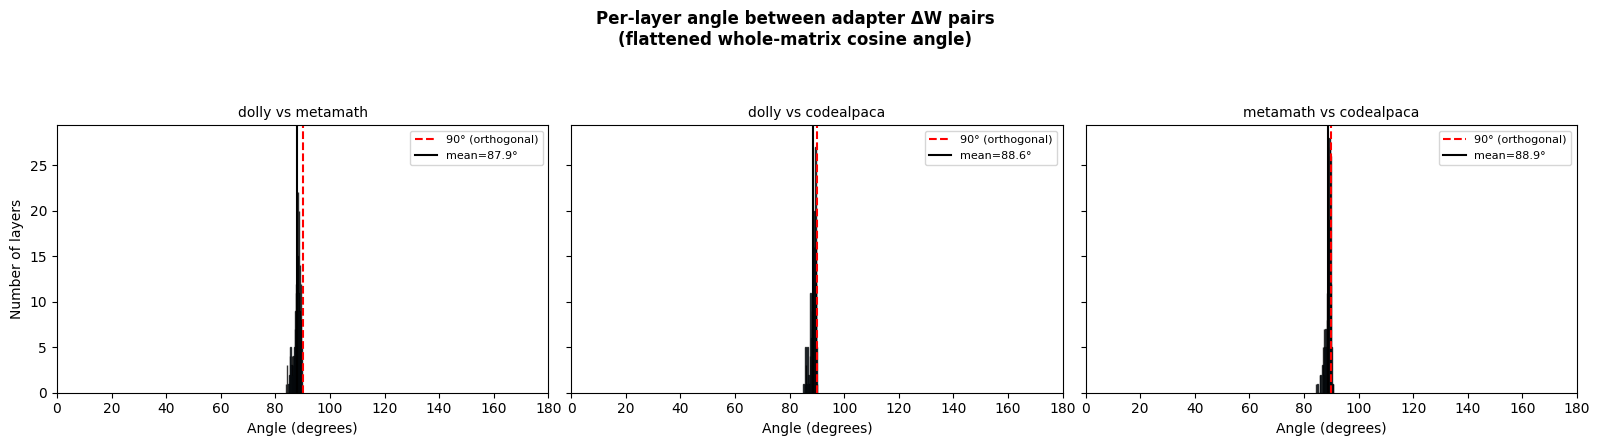

Saved: adapter_angle_distributions.png


In [4]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharey=True)

for ax, (name, angles) in zip(axes, pair_angles.items()):
    vals = list(angles.values())
    ax.hist(vals, bins=30, color="steelblue", edgecolor="black", alpha=0.8)
    ax.axvline(90, color="red", linestyle="--", linewidth=1.5, label="90° (orthogonal)")
    ax.axvline(np.mean(vals), color="black", linestyle="-", linewidth=1.5, label=f"mean={np.mean(vals):.1f}°")
    ax.set_title(name, fontsize=10)
    ax.set_xlabel("Angle (degrees)")
    ax.set_xlim(0, 180)
    ax.legend(fontsize=8)

axes[0].set_ylabel("Number of layers")
fig.suptitle("Per-layer angle between adapter ΔW pairs\n(flattened whole-matrix cosine angle)", fontsize=12, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.savefig("adapter_angle_distributions.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: adapter_angle_distributions.png")


## Interpretation

In [5]:
import numpy as np

print("═" * 70)
print("INTERPRETATION")
print("═" * 70)

for name, angles in pair_angles.items():
    vals = np.array(list(angles.values()))
    mean_a, std_a = vals.mean(), vals.std()
    near_90 = np.mean(np.abs(vals - 90) < 5)  # fraction of layers within 5° of orthogonal
    print(f"\n{name}:")
    print(f"  mean={mean_a:.2f}°  std={std_a:.2f}°  fraction within 5° of 90°: {near_90:.1%}")

ratio = None
try:
    obs_std = np.std(list(pair_angles["metamath vs codealpaca"].values()))
    ratio = obs_std / theoretical_std
    print(f"\nmetamath-vs-codealpaca observed std / theoretical random-vector std = {ratio:.2f}x")
    if ratio < 2:
        print("  → Close to theoretical random baseline: consistent with concentration of measure —")
        print("    whole-matrix angles carry little real task-similarity signal at this dimensionality.")
    else:
        print("  → Meaningfully wider than the random baseline: there IS real directional structure")
        print("    being captured — the GSM8K collapse likely has a different or additional cause")
        print("    (e.g. norm-preserving scaling, or specific unstable layers near 180°).")
except NameError:
    pass

print("\nNote: this diagnostic operates at whole-flattened-matrix granularity (one angle per")
print("weight tensor). It does NOT rule out that per-rank-direction structure (e.g. within the")
print("16 singular directions of each ΔW) carries real signal that this coarse view averages away.")


══════════════════════════════════════════════════════════════════════
INTERPRETATION
══════════════════════════════════════════════════════════════════════

dolly vs metamath:
  mean=87.90°  std=1.22°  fraction within 5° of 90°: 97.4%

dolly vs codealpaca:
  mean=88.63°  std=1.04°  fraction within 5° of 90°: 99.5%

metamath vs codealpaca:
  mean=88.87°  std=1.03°  fraction within 5° of 90°: 99.5%

metamath-vs-codealpaca observed std / theoretical random-vector std = 31.84x
  → Meaningfully wider than the random baseline: there IS real directional structure
    being captured — the GSM8K collapse likely has a different or additional cause
    (e.g. norm-preserving scaling, or specific unstable layers near 180°).

Note: this diagnostic operates at whole-flattened-matrix granularity (one angle per
weight tensor). It does NOT rule out that per-rank-direction structure (e.g. within the
16 singular directions of each ΔW) carries real signal that this coarse view averages away.


## Direction-Retention Check

The angle diagnostic above shows every adapter pair sits within ~1° of each other (87.9°–88.9°), ruling out pairwise orthogonality differences as the explanation for SLERP's selective GSM8K collapse. Next: check whether SLERP's *merged* result actually drifts away from each original adapter's direction more than linear merging does — if SLERP loses more of metamath's direction specifically, that explains the collapse.

In [6]:
from typing import Optional, Union, Dict

def slerp_merge(
    deltas: list,
    t: Optional[Union[float, list]] = None,
    eps: float = 1e-8,
) -> Dict[str, torch.Tensor]:
    """Sequential pairwise SLERP merge of N deltas (same implementation used in
    the merging notebook). t=[1/2, 1/3] for N=3 gives equal (1/3,1/3,1/3) norm
    weighting via the streaming-average schedule — see merging notebook docstring."""
    n = len(deltas)
    assert n >= 2
    if isinstance(t, float):
        assert n == 2
        t = [t]
    if t is None:
        t = [1.0 / (i + 2) for i in range(n - 1)]
    assert len(t) == n - 1

    def slerp_pair(d1, d2, t_val):
        merged = {}
        keys = set(d1.keys()) & set(d2.keys())
        for key in keys:
            v1 = d1[key].float().flatten()
            v2 = d2[key].float().flatten()
            original_shape = d1[key].shape
            n1, n2 = torch.norm(v1), torch.norm(v2)
            if n1 < eps or n2 < eps:
                merged[key] = (1 - t_val) * d1[key].float() + t_val * d2[key].float()
                continue
            v1u, v2u = v1 / n1, v2 / n2
            dot = torch.clamp(torch.dot(v1u, v2u), -1.0 + eps, 1.0 - eps)
            omega = torch.acos(dot)
            sin_omega = torch.sin(omega)
            if sin_omega.abs() < eps:
                merged[key] = (1 - t_val) * d1[key].float() + t_val * d2[key].float()
            else:
                c1 = torch.sin((1 - t_val) * omega) / sin_omega
                c2 = torch.sin(t_val * omega) / sin_omega
                interp_norm = (1 - t_val) * n1 + t_val * n2
                merged[key] = ((c1 * v1u + c2 * v2u) * interp_norm).reshape(original_shape)
        return merged

    result = deltas[0]
    for i in range(1, n):
        result = slerp_pair(result, deltas[i], t[i - 1])
    return result


In [7]:
import torch

def linear_merge_simple(deltas, weights=None):
    n = len(deltas)
    weights = weights or [1.0 / n] * n
    keys = set.intersection(*[set(d.keys()) for d in deltas])
    return {k: sum(w * d[k] for w, d in zip(weights, deltas)) for k in keys}

def cosine_to_original(merged: dict, original: dict) -> float:
    """Mean per-layer cosine similarity between a merged delta and one adapter's original delta."""
    sims = []
    for key in set(merged.keys()) & set(original.keys()):
        v1 = merged[key].flatten().float()
        v2 = original[key].flatten().float()
        n1, n2 = torch.norm(v1), torch.norm(v2)
        if n1 < 1e-8 or n2 < 1e-8:
            continue
        sims.append(torch.nn.functional.cosine_similarity(v1.unsqueeze(0), v2.unsqueeze(0)).item())
    return sum(sims) / len(sims)


deltas_list  = [dolly_deltas, metamath_deltas, codealpaca_deltas]
merged_linear = linear_merge_simple(deltas_list)
merged_slerp  = slerp_merge(deltas_list, t=[1.0/2, 1.0/3])  # same schedule used in the real pipeline

originals = {"dolly": dolly_deltas, "metamath": metamath_deltas, "codealpaca": codealpaca_deltas}

print(f"{'Adapter':<12}{'linear cos-sim':>16}{'slerp cos-sim':>16}{'slerp - linear':>16}")
print("-" * 60)
for name, orig in originals.items():
    lin_sim   = cosine_to_original(merged_linear, orig)
    slerp_sim = cosine_to_original(merged_slerp, orig)
    print(f"{name:<12}{lin_sim:>16.4f}{slerp_sim:>16.4f}{slerp_sim - lin_sim:>16.4f}")

print("\nIf slerp's cosine similarity to 'metamath' is notably lower than linear's,")
print("that directly explains the selective GSM8K collapse: SLERP's merged result")
print("retains less of metamath's original direction than a simple average does.")


Adapter       linear cos-sim   slerp cos-sim  slerp - linear
------------------------------------------------------------
dolly                 0.1986          0.6281          0.4295
metamath              0.4590          0.6260          0.1671
codealpaca            0.8814          0.5173         -0.3640

If slerp's cosine similarity to 'metamath' is notably lower than linear's,
that directly explains the selective GSM8K collapse: SLERP's merged result
retains less of metamath's original direction than a simple average does.


In [8]:
import torch

def total_norm(deltas: dict) -> float:
    """Aggregate Frobenius norm across all layers (sqrt of sum of squared norms)."""
    return sum(torch.norm(v.float()).item() ** 2 for v in deltas.values()) ** 0.5

def per_layer_norms(deltas: dict) -> dict:
    return {k: torch.norm(v.float()).item() for k, v in deltas.items()}


# ── 1. Are the original adapters' magnitudes actually different? ──
print("Original adapter total norms (aggregate Frobenius norm across all 196 layers):")
orig_norms = {}
for name, d in [("dolly", dolly_deltas), ("metamath", metamath_deltas), ("codealpaca", codealpaca_deltas)]:
    n = total_norm(d)
    orig_norms[name] = n
    print(f"  {name:<12} {n:.4f}")

print(f"\nRatio codealpaca/dolly    : {orig_norms['codealpaca']/orig_norms['dolly']:.2f}x")
print(f"Ratio codealpaca/metamath : {orig_norms['codealpaca']/orig_norms['metamath']:.2f}x")

# ── 2. How much of metamath's original magnitude survives in each merged result? ──
print("\nMerged-result norm as a fraction of metamath's original norm (per layer, averaged):")

def norm_ratio_to_original(merged: dict, original: dict) -> float:
    ratios = []
    for key in set(merged.keys()) & set(original.keys()):
        orig_n = torch.norm(original[key].float()).item()
        if orig_n < 1e-8:
            continue
        merged_n = torch.norm(merged[key].float()).item()
        ratios.append(merged_n / orig_n)
    return sum(ratios) / len(ratios)

lin_ratio_meta   = norm_ratio_to_original(merged_linear, metamath_deltas)
slerp_ratio_meta = norm_ratio_to_original(merged_slerp, metamath_deltas)
print(f"  linear : {lin_ratio_meta:.4f}  (i.e. merged delta is {lin_ratio_meta*100:.1f}% of metamath's original magnitude)")
print(f"  slerp  : {slerp_ratio_meta:.4f}  (i.e. merged delta is {slerp_ratio_meta*100:.1f}% of metamath's original magnitude)")

print("\nIf slerp's ratio is much smaller than linear's, the merged update is too weak")
print("to actually reproduce metamath's learned behavior at inference time — even though")
print("its direction is nominally closer to metamath's original direction.")

Original adapter total norms (aggregate Frobenius norm across all 196 layers):
  dolly        6.1842
  metamath     15.4020
  codealpaca   30.7433

Ratio codealpaca/dolly    : 4.97x
Ratio codealpaca/metamath : 2.00x

Merged-result norm as a fraction of metamath's original norm (per layer, averaged):
  linear : 0.7679  (i.e. merged delta is 76.8% of metamath's original magnitude)
  slerp  : 1.1253  (i.e. merged delta is 112.5% of metamath's original magnitude)

If slerp's ratio is much smaller than linear's, the merged update is too weak
to actually reproduce metamath's learned behavior at inference time — even though
its direction is nominally closer to metamath's original direction.


# Per-layer distribution and find the worst offenders:

In [9]:
import torch

def per_layer_cosine_to_original(merged: dict, original: dict) -> dict:
    sims = {}
    for key in set(merged.keys()) & set(original.keys()):
        v1 = merged[key].flatten().float()
        v2 = original[key].flatten().float()
        n1, n2 = torch.norm(v1), torch.norm(v2)
        if n1 < 1e-8 or n2 < 1e-8:
            continue
        sims[key] = torch.nn.functional.cosine_similarity(v1.unsqueeze(0), v2.unsqueeze(0)).item()
    return sims

def per_layer_norm_ratio(merged: dict, original: dict) -> dict:
    ratios = {}
    for key in set(merged.keys()) & set(original.keys()):
        orig_n = torch.norm(original[key].float()).item()
        if orig_n < 1e-8:
            continue
        ratios[key] = torch.norm(merged[key].float()).item() / orig_n
    return ratios


lin_cos   = per_layer_cosine_to_original(merged_linear, metamath_deltas)
slerp_cos = per_layer_cosine_to_original(merged_slerp, metamath_deltas)
lin_norm   = per_layer_norm_ratio(merged_linear, metamath_deltas)
slerp_norm = per_layer_norm_ratio(merged_slerp, metamath_deltas)

# ── Spread, not just mean ──
import numpy as np
for name, d in [("linear cos", lin_cos), ("slerp cos", slerp_cos),
                ("linear norm-ratio", lin_norm), ("slerp norm-ratio", slerp_norm)]:
    vals = np.array(list(d.values()))
    print(f"{name:<20} mean={vals.mean():.3f}  std={vals.std():.3f}  min={vals.min():.3f}  max={vals.max():.3f}")

# ── Layers where slerp is worst relative to linear (cosine) ──
print("\nLayers where SLERP loses the most metamath-direction similarity vs linear:")
diffs = {k: lin_cos[k] - slerp_cos[k] for k in lin_cos if k in slerp_cos}
worst = sorted(diffs.items(), key=lambda x: -x[1])[:10]
for key, diff in worst:
    print(f"  {key:<50} linear={lin_cos[key]:+.3f}  slerp={slerp_cos[key]:+.3f}  diff={diff:+.3f}")

# ── Layers where slerp's norm ratio is most extreme (very high or very low) ──
print("\nLayers where SLERP's norm ratio to metamath is most extreme (over/under-scaled):")
extreme = sorted(slerp_norm.items(), key=lambda x: abs(x[1] - 1.0))[-10:]
for key, ratio in extreme:
    print(f"  {key:<50} slerp_ratio={ratio:.3f}  linear_ratio={lin_norm.get(key, float('nan')):.3f}")

# ── Check whether the worst layers cluster by type or depth ──
print("\nLayer-type breakdown of the 10 worst cosine-diff layers:")
from collections import Counter
types = Counter()
for key, _ in worst:
    for t in ["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"]:
        if t in key:
            types[t] += 1
            break
print(dict(types))

linear cos           mean=0.459  std=0.035  min=0.302  max=0.549
slerp cos            mean=0.626  std=0.009  min=0.613  max=0.660
linear norm-ratio    mean=0.768  std=0.060  min=0.684  max=1.155
slerp norm-ratio     mean=1.125  std=0.071  min=1.017  max=1.573

Layers where SLERP loses the most metamath-direction similarity vs linear:
  base_model.model.model.layers.1.self_attn.v_proj.  linear=+0.549  slerp=+0.660  diff=-0.111
  base_model.model.model.layers.4.self_attn.q_proj.  linear=+0.510  slerp=+0.626  diff=-0.116
  base_model.model.model.layers.3.self_attn.k_proj.  linear=+0.507  slerp=+0.626  diff=-0.119
  base_model.model.model.layers.17.self_attn.q_proj. linear=+0.514  slerp=+0.633  diff=-0.119
  base_model.model.model.layers.27.self_attn.q_proj. linear=+0.502  slerp=+0.621  diff=-0.119
  base_model.model.model.layers.12.self_attn.v_proj. linear=+0.524  slerp=+0.644  diff=-0.120
  base_model.model.model.layers.18.self_attn.k_proj. linear=+0.514  slerp=+0.637  diff=-0.123
  base